In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/INTERNSHIP/PlantVillage')

['train', 'val']

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random
import numpy as np
import math

In [4]:
DATASET_DIR = '/content/drive/MyDrive/INTERNSHIP/PlantVillage/train'

class_counts = {}

for disease in os.listdir(DATASET_DIR):
    disease_path = os.path.join(DATASET_DIR, disease)
    if os.path.isdir(disease_path):
        class_counts[disease] = len(os.listdir(disease_path))

df_classes = pd.DataFrame(
    class_counts.items(),
    columns=['Disease', 'Image_Count']
).sort_values(by='Image_Count', ascending=False)
df_classes = df_classes.reset_index(drop=True)

df_classes

,Disease,Image_Count
0,Orange___Haunglongbing_(Citrus_greening),4405
1,Tomato___Tomato_Yellow_Leaf_Curl_Virus,4286
2,Soybean___healthy,4072
3,Peach___Bacterial_spot,1838
4,Tomato___Bacterial_spot,1702
5,Tomato___Late_blight,1527
6,Squash___Powdery_mildew,1468
7,Tomato___Septoria_leaf_spot,1417
8,Tomato___Spider_mites Two-spotted_spider_mite,1341
9,Apple___healthy,1316


In [5]:
classes = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

print("Total number of classes:", len(classes))
print("\nList of classes:\n")

for c in classes:
    print(c)

healthy_classes = [c for c in classes if "healthy" in c.lower()]
disease_classes = [c for c in classes if "healthy" not in c.lower()]

print("\nNumber of healthy classes:", len(healthy_classes))
print("Number of disease classes:", len(disease_classes))

Total number of classes: 38

List of classes:

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato

In [6]:
total_images = df_classes["Image_Count"].sum()
print("Total number of images:", total_images)

Total number of images: 43447


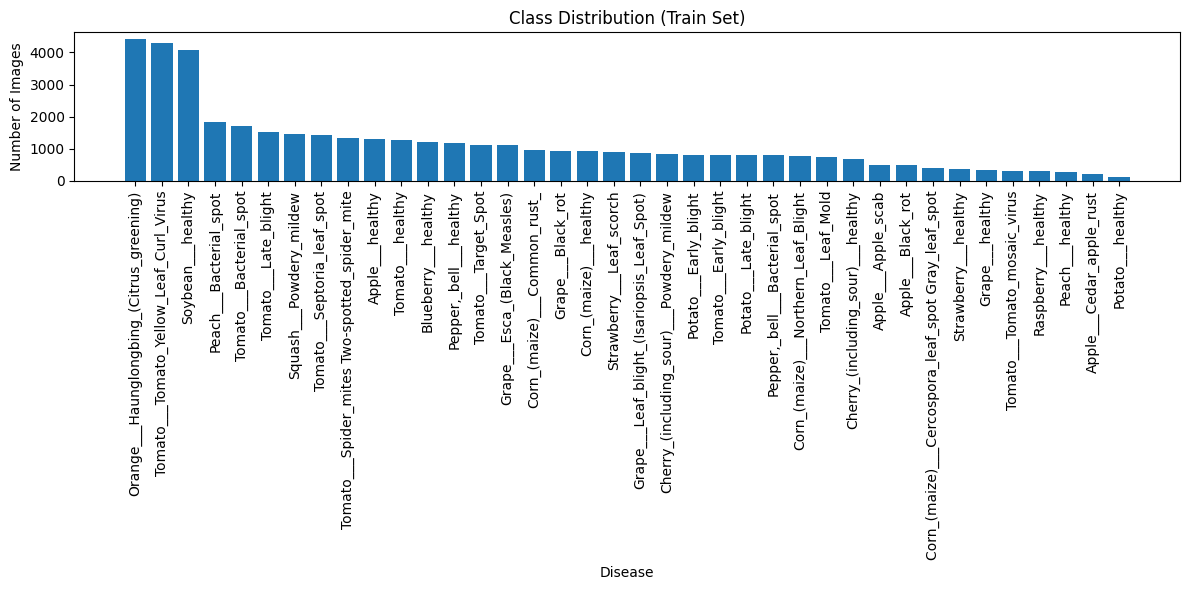

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(df_classes['Disease'], df_classes['Image_Count'])
plt.xticks(rotation=90)
plt.title('Class Distribution (Train Set)')
plt.xlabel('Disease')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

In [8]:
widths = []
heights = []
aspect_ratios = []

for disease in os.listdir(DATASET_DIR):
    disease_path = os.path.join(DATASET_DIR, disease)
    if os.path.isdir(disease_path):
        for img_name in os.listdir(disease_path):
            img_path = os.path.join(disease_path, img_name)
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
                    aspect_ratios.append(w / h)
            except:
                pass

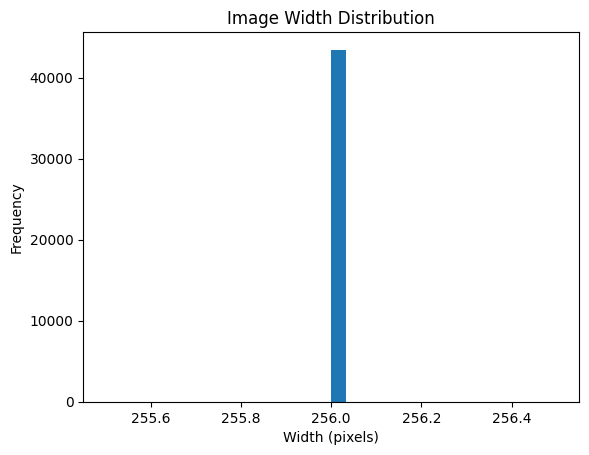

In [9]:
plt.hist(widths, bins=30)
plt.title('Image Width Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')
plt.show()

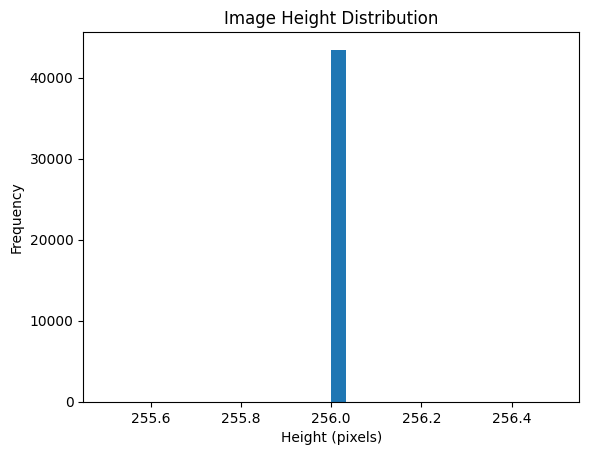

In [10]:
plt.hist(heights, bins=30)
plt.title('Image Height Distribution')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')
plt.show()

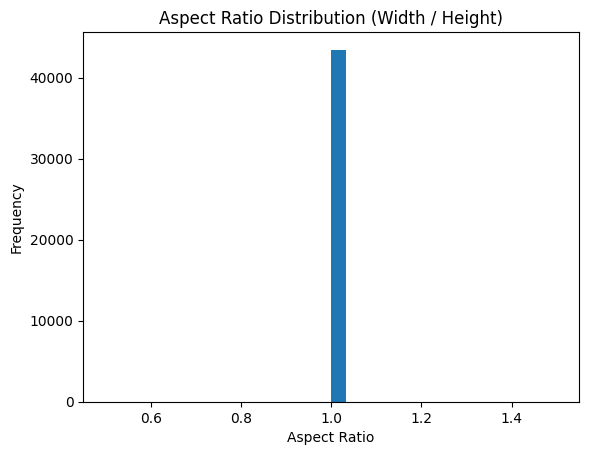

In [11]:
plt.hist(aspect_ratios, bins=30)
plt.title('Aspect Ratio Distribution (Width / Height)')
plt.xlabel('Aspect Ratio')
plt.ylabel('Frequency')
plt.show()

In [12]:
sample_class = classes[0]
sample_image_path = os.path.join(
    DATASET_DIR,
    sample_class,
    os.listdir(os.path.join(DATASET_DIR, sample_class))[0]
)

img = Image.open(sample_image_path)
img_array = np.array(img)

print("Image mode:", img.mode)
print("Image shape:", img_array.shape)

Image mode: RGB
Image shape: (256, 256, 3)


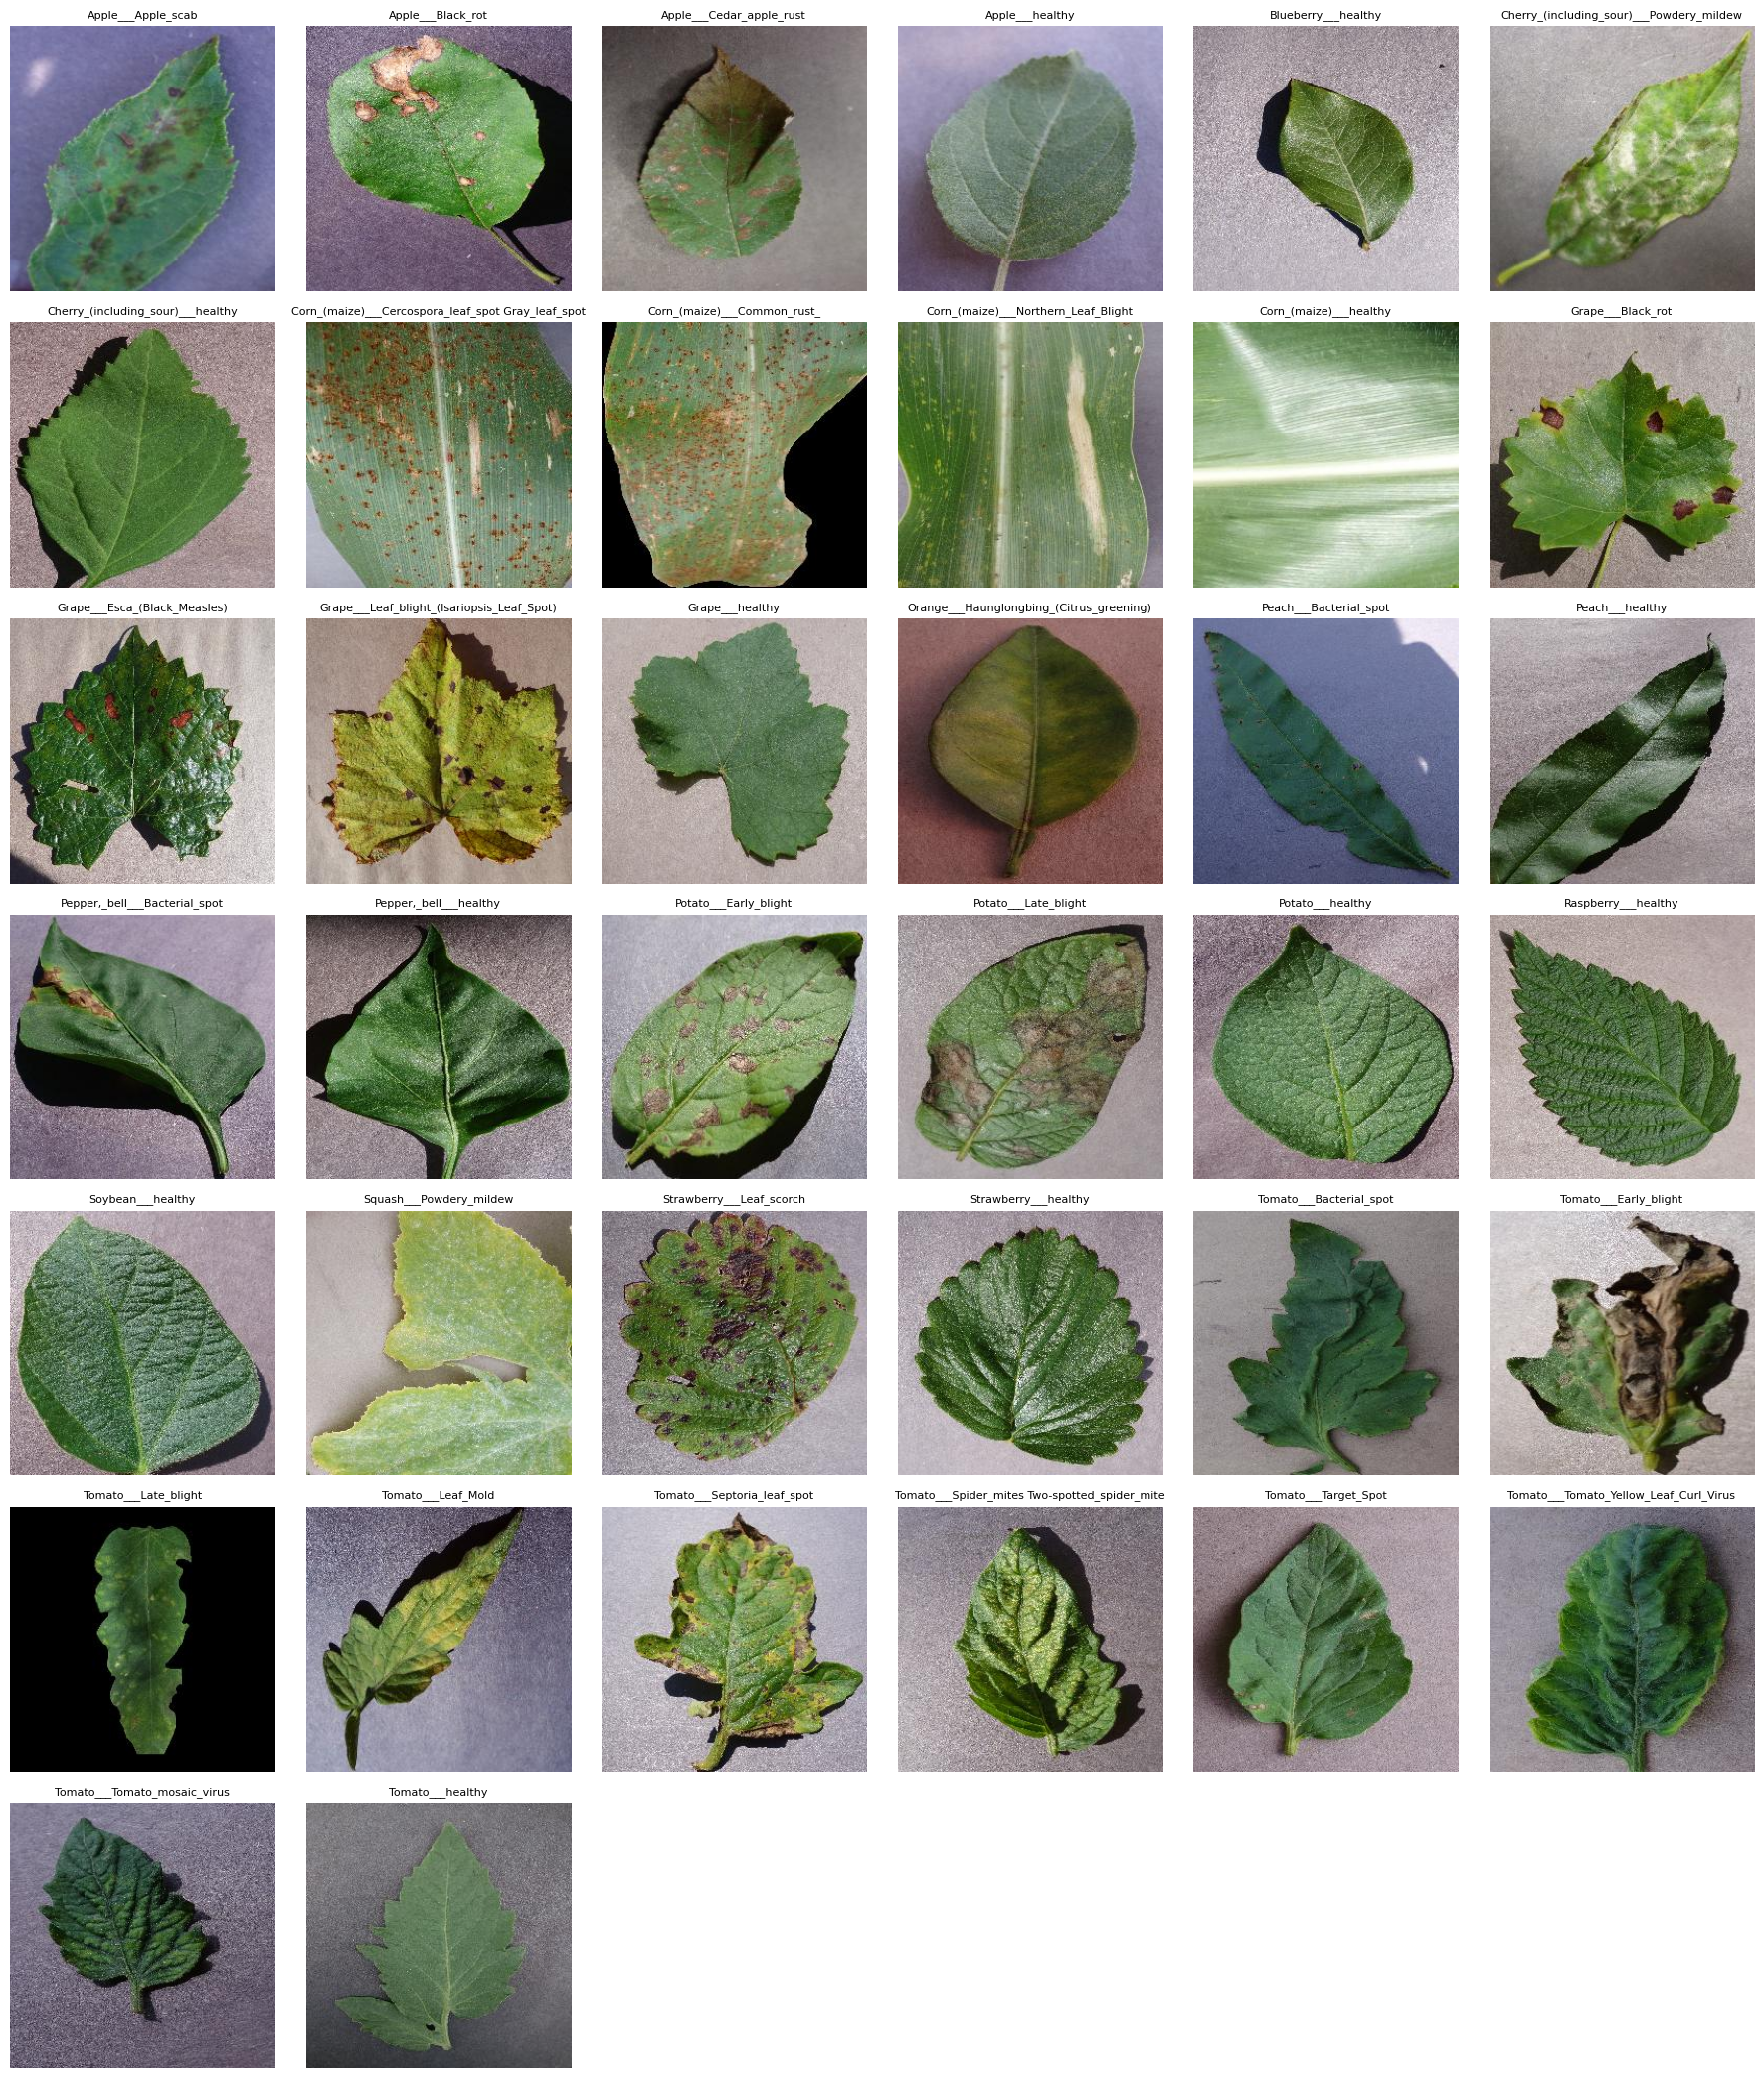

In [16]:
num_classes = len(classes)
cols = 6
rows = math.ceil(num_classes / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i, disease in enumerate(classes):
    img_folder = os.path.join(DATASET_DIR, disease)
    img_name = random.choice(os.listdir(img_folder))
    img_path = os.path.join(img_folder, img_name)

    img = Image.open(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(disease, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
grayscale_count = 0
total_images_checked = 0

for disease in classes:
    disease_path = os.path.join(DATASET_DIR, disease)
    for img_name in os.listdir(disease_path):
        img_path = os.path.join(disease_path, img_name)
        try:
            img = Image.open(img_path)
            total_images_checked += 1
            if img.mode == "L":
                grayscale_count += 1
        except:
            pass

print("Total images checked:", total_images_checked)
print("Grayscale images:", grayscale_count)

Total images checked: 43447
Grayscale images: 0


In [18]:
corrupt_images = []

for disease in classes:
    disease_path = os.path.join(DATASET_DIR, disease)
    for img_name in os.listdir(disease_path):
        img_path = os.path.join(disease_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()  # checks integrity
        except:
            corrupt_images.append(img_path)

print("Number of corrupted images:", len(corrupt_images))

if len(corrupt_images) > 0:
    print("\nSample corrupted images:")
    for img in corrupt_images[:5]:
        print(img)

Number of corrupted images: 0
